In [1]:
import bldw
import numpy as np
import blimpy as bl
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
import setigen as stg
from astropy import units as u
%matplotlib inline

plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

numexpr.utils   INFO     Note: NumExpr detected 40 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
numexpr.utils   INFO     NumExpr defaulting to 8 threads.


In [ ]:
file = '/datax/scratch/gillislowry/converted_atlas/AI-ATLAS_20260218_010037_0_chan143-143_lane0_beam0.h5'
fb = bl.Waterfall(file, load_data=False)

In [3]:
fb.info()


--- File Info ---
DIMENSION_LABELS : [b'time' b'feed_id' b'frequency']
        az_start :                              0.0
        chan_idx :                              143
       data_type :                                1
            fch1 :            27.83203274011612 MHz
            foff :       2.9802322387695312e-06 MHz
           ibeam :                                0
      machine_id :                                0
          nbeams :                                0
           nbits :                                8
          nchans :                         12582912
            nifs :                                4
    nof_beamlets :                              192
     rawdatafile :                          unknown
     source_name :                          unknown
         src_dej :                          0:00:00
         src_raj :                          0:00:00
    telescope_id :                                0
           tsamp :                       0.3

In [6]:
(2388-1)*0.33554432

800.94429184

In [7]:
2.9802322387695/800.94429184

0.0037208982811064765

In [8]:
12582912/12

1048576.0

In [ ]:
outdir = '/datax/scratch/benjb/nenufar_test/'
console = f'bliss_find_hits /datax/scratch/gillislowry/converted_atlas/AI-ATLAS_20260218_010037_0_chan143-143_lane0_beam0.h5 -d cuda:1 -md -2 -MD 2 -s 10 --number-coarse 1 -c 0 --nchan-per-coarse 1048576 --distance 30 --output /datax/scratch/benjb/nenufar_test/0218_beam0_nosig_nosk_SNR_10_L1_30.dat'
os.system(console)

In [19]:
import hdf5plugin
import h5py
with h5py.File('/datax/scratch/benjb/single_coarse_guppi_59046_80036_DIAG_VOYAGER-1_0011.rawspec.0000.h5', 'r') as f:
    dset = f['data']
    print(dset.shape)
    print(dset.chunks)

(16, 1, 1048576)
(1, 1, 16384)


In [11]:
print(dset.compression)
print(dset.compression_opts)
print(dset.chunks)
print(dset.filters if hasattr(dset, "filters") else "no filters")

None
None
(10, 1, 49152)
no filters


In [ ]:
import hdf5plugin
import h5py 
import itertools

file_path = '/datax/scratch/benjb/nenufar_test/AI-ATLAS_20260218_010037_0_chan143-143_lane0_beam0.h5'

with h5py.File(file_path, 'a') as f:
    # read existing dataset
    del f['data_tmp']
    dset = f['data']
    print(dset)
    
    # get metadata
    attrs = dict(dset.attrs)
    shape = dset.shape
    chunks = dset.chunks
    compression = dset.compression
    compression_opts = dset.compression_opts

    new_shape = (shape[0], 1, shape[2])
    new_chunks = (dset.chunks[0], 1, dset.chunks[2])

    # create new dataset with same name
    dset_new = f.create_dataset(
        'data_tmp',
        shape=new_shape,
        dtype=np.float32,
        chunks=new_chunks,
        compression=compression,
        compression_opts=compression_opts,
    )

    # copy chunk by chunk
    chunk0, _, chunk2 = dset.chunks

    for i in range(0, shape[0], chunk0):
        i_end = min(i + chunk0, shape[0])

        for k in range(0, shape[2], chunk2):
            if (i%10==0)&(k==0):
                print(f'{i} of {shape[0]}, {k} of {shape[2]}')
                
            k_end = min(k + chunk2, shape[2])

            # Read only the first slice of axis 1
            data = dset[i:i_end, 0:1, k:k_end]

            # Convert and write
            dset_new[i:i_end, 0:1, k:k_end] = data.astype(np.float32)

    # restore attributes
    for key, value in attrs.items():
        dset_new.attrs[key] = value

    # add new attribute
    dset_new.attrs['nfpc'] = shape[-1] // 12

    # replace old dataset
    del f['data']
    f.move('data_tmp', 'data')

<HDF5 dataset "data": shape (2388, 4, 12582912), type "|u1">
0 of 2388, 0 of 12582912
10 of 2388, 0 of 12582912
20 of 2388, 0 of 12582912
30 of 2388, 0 of 12582912
40 of 2388, 0 of 12582912
50 of 2388, 0 of 12582912
60 of 2388, 0 of 12582912
70 of 2388, 0 of 12582912
80 of 2388, 0 of 12582912
90 of 2388, 0 of 12582912
100 of 2388, 0 of 12582912
110 of 2388, 0 of 12582912
120 of 2388, 0 of 12582912
130 of 2388, 0 of 12582912
140 of 2388, 0 of 12582912
150 of 2388, 0 of 12582912
160 of 2388, 0 of 12582912
170 of 2388, 0 of 12582912
180 of 2388, 0 of 12582912
190 of 2388, 0 of 12582912
200 of 2388, 0 of 12582912
210 of 2388, 0 of 12582912
220 of 2388, 0 of 12582912
230 of 2388, 0 of 12582912
240 of 2388, 0 of 12582912
250 of 2388, 0 of 12582912
260 of 2388, 0 of 12582912
270 of 2388, 0 of 12582912
280 of 2388, 0 of 12582912
290 of 2388, 0 of 12582912
300 of 2388, 0 of 12582912
310 of 2388, 0 of 12582912
320 of 2388, 0 of 12582912
330 of 2388, 0 of 12582912
340 of 2388, 0 of 12582912
350 o

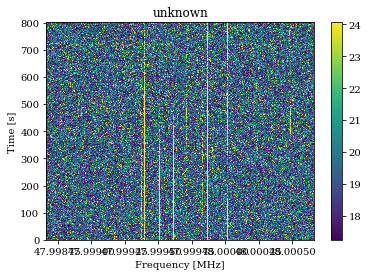

In [29]:
cf = 47.999664 
fb = bl.Waterfall('/datax/scratch/benjb/nenufar_test/AI-ATLAS_20260218_010037_0_chan143-143_lane0_beam0.h5', f_start=cf-0.001, f_stop=cf+0.001)
fb.plot_waterfall()

In [33]:
1048576/4

262144.0